In [21]:
import cv2
import torch
import numpy as np
from torch import nn
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
def pipette_color(image: np.ndarray, k: int = 4) -> tuple[int, int, int]:
    if image.ndim != 3 or image.shape[2] != 3:
        raise ValueError("Expected HSV image with 3 channels")

    X = image.reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels, _ = cv2.kmeans(X, k, None, criteria, 5, cv2.KMEANS_PP_CENTERS)

    labels = labels.ravel()
    dom = np.bincount(labels).argmax()
    c = X[labels == dom]

    return tuple(map(int, np.median(c, axis=0)))

# poprawic zeby ze srodka

In [13]:
img = cv2.imread('/Users/polymorvic/development/tennis-court-detection/data/pics/01_01.png')
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [14]:
pipette_color(img_hsv)[0]

104

In [15]:
pics_dir = Path('data/pics')

hues = []
for path in tqdm(pics_dir.glob('*.png')):
    img = cv2.imread(path)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hue_value = pipette_color(img_hsv)[0]
    hues.append(hue_value)

1050it [08:36,  2.03it/s]


(array([  1.,  20.,   0.,   9.,   3.,   0.,  57.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   3.,   0.,   5.,  38.,   0., 150.,   1.,   0.,  33.,  55.,
          0.,  56.,  13.,   0.,   2.,   1.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   9.,  11.,   0.,   9.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,  43., 107.,   0.,  30., 

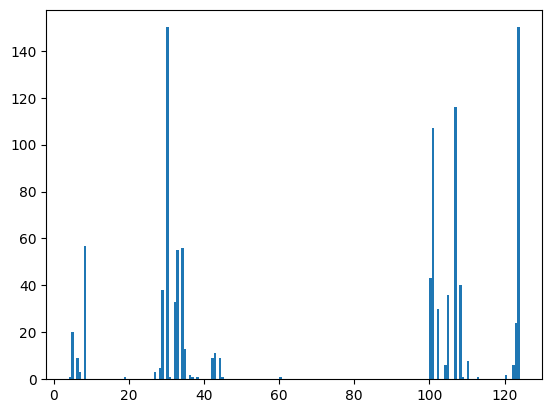

In [20]:
plt.hist(hues, bins=180)

In [25]:
from sklearn.model_selection import train_test_split
from collections import defaultdict

In [26]:
images_path = Path('data/pics')
skip_images_path = Path('data/pics/skip')

In [31]:
images = [file.name for file in images_path.glob('*.png')]
skip_images = [file.name for file in skip_images_path.glob('*.png')]


skip_train, skip_temp = train_test_split(skip_images, test_size=0.3, random_state=123)
skip_val, skip_test = train_test_split(skip_temp, test_size=0.5, random_state=123)

img_color_split = defaultdict(list)
for name in images:
    img = cv2.cvtColor(cv2.imread(str(images_path / name)), cv2.COLOR_BGR2HSV)
    hue_value = pipette_color(img)[0]
    
    if 0 <= hue_value < 15:
        img_color_split['color_group_1'].append(name)

    elif 15 <= hue_value < 50:
        img_color_split['color_group_2'].append(name)

    elif 50 <= hue_value < 115:
        img_color_split['color_group_3'].append(name)

    else:
        img_color_split['color_group_4'].append(name)

img_color_dataset = {}
img_color_dataset_length = {}
for key, img_names in img_color_split.items():

    img_train, img_temp = train_test_split(img_names, test_size=0.3, random_state=123)
    img_val, img_test = train_test_split(img_temp, test_size=0.5, random_state=123)

    img_color_dataset[key] = img_train, img_val, img_test
    img_color_dataset_length[key] = len(img_train), len(img_val), len(img_test)


img_datasets = ([], [], [])
skip_datasets = (skip_train, skip_val, skip_test)
for t in range(3):
    m = max([val[t] for val in img_color_dataset_length.values()])


    for i in range(m):
        should_break = False
        for val in img_color_dataset.values():

            try:
                img = val[t][i]

            except Exception:
                continue

            img_datasets[t].append(img)

            if len(img_datasets[t]) == len(skip_datasets[t]):
                should_break = True
                break

        if should_break:
            break

In [42]:
len(img_color_dataset['color_group_1'][0])
len(img_color_dataset['color_group_1'][1])
len(img_color_dataset['color_group_1'][2])

14

In [44]:
len(img_color_dataset['color_group_2'][0])
# len(img_color_dataset['color_group_2'][1])
# len(img_color_dataset['color_group_2'][2])

273

In [ ]:
# img_name,label,match
# pic_08_25_02,1,m_pic
# skip_m10_0050,0,skip_m10
# skip_m07_0618,0,skip_m07
# skip_m03_0248,0,skip_m03
# skip_m09_0015,0,skip_m09
# skip_m07_0592,0,skip_m07

In [53]:
dataset_names = (['train', 'val', 'test'])
dfs = []
for t in range(3):

    print(len(img_datasets[t]), len(skip_datasets[t]))

    df = pd.DataFrame({
        'img_name': img_datasets[t] + skip_datasets[t],
        'dataset': [dataset_names[t]] * (len(img_datasets[t]) + len(skip_datasets[t])),
        'label': [1] * len(img_datasets[t]) + [0] * len(skip_datasets[t])
    })
    dfs.append(df)

df_main = pd.concat(dfs)

609 609
130 130
131 131


In [56]:
df_main.to_csv('data/shot_classification_split_data.csv', index=False)

In [161]:
# for i, row in df_main[df_main['dataset']=='train'].iterrows():
#     img_name = row['img_name']
#     label = row['label']

#     img = cv2.cvtColor(cv2.imread(str(images_path / img_name)), cv2.COLOR_BGR2RGB)

#     plt.imshow(img)
#     plt.title(f'{img_name} - label: {label}')
#     plt.axis('off')
#     plt.show()

In [110]:
from torch.utils.data import Dataset
from typing import Literal

In [111]:
import torch
from torchvision.transforms import Compose, Resize, Normalize, ToPILImage, ToTensor

from torch import nn

class MinMaxTransform(torch.nn.Module):
    def forward(self, img: torch.Tensor) -> torch.Tensor:
        return img.float().div(255.0)
    

def compose_transform(*ops: nn.Module) -> Compose:

    return Compose([
        ToPILImage(),
        Resize((224, 224)),
        ToTensor(),
        MinMaxTransform(),
        Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        *ops
        ])
    

transform = compose_transform()

In [112]:
class ShotDataset(Dataset):
    def __init__(self, split_spec_path: str | Path, pics_root: str | Path, mode: Literal['train', 'val', 'test']):
        self.pics_root = Path(pics_root)

        data = pd.read_csv(split_spec_path)
        self.data = data[data["dataset"] == mode].sample(frac=1).reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.data)

    def _img_path(self, img_name: str) -> Path:
        subdir = "skip" if "skip_" in img_name else "."
        if not img_name.endswith('.png'):
            img_name += '.png'
        return self.pics_root / subdir / img_name

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        row = self.data.iloc[idx]
        img_path = self._img_path(row["img_name"])
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        img_tensor = transform(img)
        label = torch.tensor(row["label"], dtype=torch.float32)
        return img_tensor, label

In [141]:
# def image_to_tensor(img: np.ndarray, resize: tuple[int, int] | None = None, with_batch_size: bool = True) -> torch.Tensor:
#     if resize is not None:
#         img = cv2.resize(img, resize)

#     if img.ndim == 2:
#         img = img[:, :, np.newaxis]

#     img_tensor = torch.from_numpy(img).permute(2, 0, 1).float()
#     return img_tensor.unsqueeze(0) if with_batch_size else img_tensor


# def tensor_to_image(img_tensor: torch.Tensor) -> np.ndarray:
#     if img_tensor.shape[0] > 1:
#         raise ValueError("batch size must be equals to 1")
    
#     img_arr = img_tensor.detach().numpy()
#     return img_arr.squeeze()


# def prepare_img_for_resnet(img: np.ndarray):
#     img = cv2.resize(img, (224, 224)).astype(np.float32)
#     img /= 255
#     img_tensor = torch.tensor(img).permute(2, 0, 1).float()# .unsqueeze(0)
#     return torchvision.transforms.functional.normalize(img_tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

In [142]:
train_dataset = ShotDataset('data/shot_classification_split_data.csv', 'data/pics', 'train')
val_dataset = ShotDataset('data/shot_classification_split_data.csv', 'data/pics', 'val')
test_dataset = ShotDataset('data/shot_classification_split_data.csv', 'data/pics', 'test')

In [143]:
from torch.utils.data import DataLoader

In [144]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32)
test_dataloader = DataLoader(test_dataset, batch_size=32)

In [145]:
from torchvision import models

In [146]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

In [162]:
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/polymorvic/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 37.8MB/s]


In [163]:
model.fc.in_features # liczba cech do glowy

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 1),
)

In [164]:
for name, param in model.named_parameters():
    if not name.startswith(('fc', 
                            # 'layer4.1.conv2.weight', 'layer4.1.bn2.weight', 'layer4.1.bn2.bias', 
                            #  'layer4.1.conv1.weight', 'layer4.1.bn1.weight', 'layer4.1.bn1.bias', 
                            
                            # 'layer4.0.conv1.weight', 'layer4.0.bn1.weight', 'layer4.0.bn1.bias',
                            # 'layer4.0.conv2.weight', 'layer4.0.bn2.weight', 'layer4.0.bn2.bias'
                            
                            )): 
        param.requires_grad = False

In [165]:
from pydantic import BaseModel
import torch.nn.functional as F

In [166]:
class History(BaseModel):
    epoch_losses: list[float] = []
    epoch_accuracy: list[float] = []
    step_losses: list[float] = []
    best_loss: float = np.inf
    best_accuracy: float = 0
    _running_loss: float
    _correct_pred: float

    def on_epoch_start(self) -> None:
        self._running_loss = .0
        self._correct_pred = .0

    def on_epoch_end(self, dataset: Dataset, focus: Literal['loss', 'accuracy']) -> bool:
        """
        Czy dana epoka polepszyla model wzgledem treningu na podstawie metryki przekazywanej w argumencie focus
        """
        current_loss = self._running_loss / len(dataset)
        current_accuracy = self._correct_pred / len(dataset)
        self.epoch_losses.append(current_loss)
        self.epoch_accuracy.append(current_accuracy)

        if is_better_loss := current_loss < self.best_loss:
            self.best_loss = current_loss
  
        if is_better_accuracy := current_accuracy > self.best_accuracy:
            self.best_accuracy = current_accuracy

        return  {'loss': is_better_loss, 'accuracy': is_better_accuracy}[focus]

        
    def on_step_end(self, loss: float, y_hat: torch.Tensor, y_gt: torch.Tensor) -> None:
        y_pred = (F.sigmoid(y_hat).reshape(-1) >= 0.5).long()
        self._correct_pred += (y_pred == y_gt).sum().item()
        self._running_loss += loss
        self.step_losses.append(loss)

        

    def get_latest(self, mode: Literal['train', 'val']) -> str:
        return f"{mode} loss= {self.epoch_losses[-1]:.4f} {mode} accuracy= {self.epoch_accuracy[-1]:.4f}"

In [167]:
import random

In [168]:
torch.manual_seed(123)
np.random.seed(123)
random.seed(123)


criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
epochs_num = 10
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=4)
focus = "loss"
model = model.to(device)

train_hist = History()
val_hist = History()
learning_rates = []

for ep in range(epochs_num):
    model.train()

    train_hist.on_epoch_start()

    for batch_x, batch_y in train_dataloader:
        optimizer.zero_grad()
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)  
        y_hat = model(batch_x)

        loss = criterion(y_hat, batch_y.reshape(-1, 1))
        loss.backward()
        optimizer.step()
        train_hist.on_step_end(loss.item(), y_hat, batch_y)

    train_hist.on_epoch_end(train_dataset, focus)
    model.eval()
    val_hist.on_epoch_start()
    with torch.no_grad():

        for batch_x, batch_y in val_dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            y_hat = model(batch_x)

            loss = criterion(y_hat, batch_y.reshape(-1, 1))
            val_hist.on_step_end(loss.item(), y_hat, batch_y)


    save_best_model = val_hist.on_epoch_end(val_dataset, focus)
    scheduler.step(val_hist.epoch_losses[-1])
    learning_rates.append(optimizer.param_groups[0]['lr'])
    print(f"Epoka {ep+1}/{epochs_num}: {train_hist.get_latest(mode='train')}, {val_hist.get_latest('val')}")

    checkpoint_data = {"model": model.state_dict(), "optimizer": optimizer.state_dict(), "epoch": ep + 1}
    torch.save(checkpoint_data, 'models/shot-classifier-last.pt')
    if save_best_model:
        torch.save(checkpoint_data, 'models/shot-classifier-best.pt')


Epoka 1/10: train loss= 0.0210 train accuracy= 0.6872, val loss= 0.0242 val accuracy= 0.5000
Epoka 2/10: train loss= 0.0161 train accuracy= 0.9269, val loss= 0.0177 val accuracy= 0.8769
Epoka 3/10: train loss= 0.0103 train accuracy= 0.9401, val loss= 0.0083 val accuracy= 0.9615
Epoka 4/10: train loss= 0.0064 train accuracy= 0.9713, val loss= 0.0049 val accuracy= 0.9769
Epoka 5/10: train loss= 0.0040 train accuracy= 0.9787, val loss= 0.0036 val accuracy= 0.9769
Epoka 6/10: train loss= 0.0032 train accuracy= 0.9762, val loss= 0.0031 val accuracy= 0.9808
Epoka 7/10: train loss= 0.0025 train accuracy= 0.9828, val loss= 0.0025 val accuracy= 0.9846
Epoka 8/10: train loss= 0.0021 train accuracy= 0.9885, val loss= 0.0023 val accuracy= 0.9846
Epoka 9/10: train loss= 0.0017 train accuracy= 0.9910, val loss= 0.0021 val accuracy= 0.9808
Epoka 10/10: train loss= 0.0019 train accuracy= 0.9910, val loss= 0.0018 val accuracy= 0.9808


In [169]:
model.eval()

with torch.no_grad():
    test_loss = .0
    correct_pred = .0

    for batch_x, batch_y in test_dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        y_hat = model(batch_x)

        loss = criterion(y_hat, batch_y.reshape(-1, 1))
        test_loss += loss.item()

        y_pred = (F.sigmoid(y_hat).reshape(-1) >= 0.5).long()
        correct_pred += (y_pred == batch_y).sum().item()

    test_loss /= len(test_dataloader.dataset)
    test_accuracy = correct_pred / len(test_dataloader.dataset)

In [170]:
test_accuracy

0.9885496183206107